### 环境配置

In [1]:
print("test")

test


In [2]:
pip install pandas scikit-learn matplotlib

Looking in indexes: http://mirrors.aliyun.com/pypi/simple/
     ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
     - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
     ---- ----------------------------------- 1.0/9.9 MB 2.6 MB/s eta 0:00:04
     ----- ---------------------------------- 1.3/9.9 MB 2.1 MB/s eta 0:00:05
     ------- -------------------------------- 1.8/9.9 MB 2.1 MB/s eta 0:00:04
     -------- ------------------------------- 2.1/9.9 MB 1.9 MB/s eta 0:00:05
     --------- ------------------------------ 2.4/9.9 MB 1.8 MB/s eta 0:00:05
     ---------- ----------------------------- 2.6/9.9 MB 1.8 MB/s eta 0:00:05
     ----------- ---------------------------- 2.9/9.9 MB 1.7 MB/s eta 0:00:05
     ------------- -------------------------- 3.4/9.9 MB 1.8 MB/s eta 0:00:04
     -------------- -------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
pd.options.display.max_columns = 30
import matplotlib.pyplot as plt

In [3]:
# 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
df = pd.read_csv('Seattle_Hotels.csv', encoding="latin-1")
# 数据探索
print(df.head())
print('数据集中的酒店个数：', len(df))

                             name  \
0  Hilton Garden Seattle Downtown   
1          Sheraton Grand Seattle   
2   Crowne Plaza Seattle Downtown   
3   Kimpton Hotel Monaco Seattle    
4              The Westin Seattle   

                                           address  \
0  1821 Boren Avenue, Seattle Washington 98101 USA   
1   1400 6th Avenue, Seattle, Washington 98101 USA   
2                  1113 6th Ave, Seattle, WA 98101   
3                   1101 4th Ave, Seattle, WA98101   
4   1900 5th Avenue, Seattle, Washington 98101 USA   

                                                desc  
0  Located on the southern tip of Lake Union, the...  
1  Located in the city's vibrant core, the Sherat...  
2  Located in the heart of downtown Seattle, the ...  
3  What?s near our hotel downtown Seattle locatio...  
4  Situated amid incredible shopping and iconic a...  
数据集中的酒店个数： 152


In [13]:
print('第10个酒店的描述：')
data_10=df.iloc[10][['name','desc']]
print(data_10)
print("numpy",data_10.values)
print("-----------\nnumpy",data_10.values[0])

第10个酒店的描述：
name                                            W Seattle
desc    Soak up the vibrant scene in the Living Room B...
Name: 10, dtype: str
numpy <StringArray>
['W Seattle', 'Soak up the vibrant scene in the Living Room Bar and get in the mix with our live music and DJ series before heading to a memorable dinner at TRACE. Offering inspired seasonal fare in an award-winning atmosphere, it's a not-to-be-missed culinary experience in downtown Seattle. Work it all off the next morning at FIT®, our state-of-the-art fitness center before wandering out to explore many of the area's nearby attractions, including Pike Place Market, Pioneer Square and the Seattle Art Museum. As always, we've got you covered during your time at W Seattle with our signature Whatever/Whenever® service - your wish is truly our command.']
Length: 2, dtype: str
-----------
numpy W Seattle


In [10]:
name_10=data_10['name']
desc_10 =data_10['desc']
print(f'name:{name_10}\n,desc_10:{desc_10}')

name:W Seattle
,desc_10:Soak up the vibrant scene in the Living Room Bar and get in the mix with our live music and DJ series before heading to a memorable dinner at TRACE. Offering inspired seasonal fare in an award-winning atmosphere, it's a not-to-be-missed culinary experience in downtown Seattle. Work it all off the next morning at FIT®, our state-of-the-art fitness center before wandering out to explore many of the area's nearby attractions, including Pike Place Market, Pioneer Square and the Seattle Art Museum. As always, we've got you covered during your time at W Seattle with our signature Whatever/Whenever® service - your wish is truly our command.


In [16]:
# 条件
print(df[df.index==10][['name','desc']].values)

[['W Seattle'
  "Soak up the vibrant scene in the Living Room Bar and get in the mix with our live music and DJ series before heading to a memorable dinner at TRACE. Offering inspired seasonal fare in an award-winning atmosphere, it's a not-to-be-missed culinary experience in downtown Seattle. Work it all off the next morning at FIT®, our state-of-the-art fitness center before wandering out to explore many of the area's nearby attractions, including Pike Place Market, Pioneer Square and the Seattle Art Museum. As always, we've got you covered during your time at W Seattle with our signature Whatever/Whenever® service - your wish is truly our command."]]


### 自用英语停用词

In [17]:

# 创建英文停用词列表
ENGLISH_STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', 
    "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 
    'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 
    'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 
    'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 
    'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 
    'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 
    "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', 
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', 
    "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

In [21]:
# 统计ngram词频矩阵，使用自定义停用词列表
n = 3
corpus = df['desc']
vec = CountVectorizer(ngram_range=(n, n), stop_words=list(ENGLISH_STOPWORDS)).fit(corpus)
print(vec)

CountVectorizer(ngram_range=(3, 3),
                stop_words=['here', 'by', 'can', 'am', 'on', 'yourselves',
                            'theirs', 'in', 'down', 'her', 'mustn', 'itself',
                            'should', 'doesn', "she's", 'only', "isn't",
                            "you'd", 'having', 'which', 'each', 'such', 'few',
                            'his', 'below', 'very', 's', 'o', 'to', "wouldn't", ...])


In [24]:
bag_of_words = vec.transform(corpus)
print(type(bag_of_words))
print(bag_of_words)

<class 'scipy.sparse._csr.csr_matrix'>
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 14917 stored elements and shape (152, 13761)>
  Coords	Values
  (0, 2)	1
  (0, 122)	1
  (0, 126)	1
  (0, 342)	1
  (0, 545)	1
  (0, 646)	1
  (0, 718)	1
  (0, 858)	1
  (0, 949)	1
  (0, 1233)	1
  (0, 1268)	1
  (0, 1529)	1
  (0, 1691)	1
  (0, 1843)	1
  (0, 1862)	1
  (0, 2159)	1
  (0, 2166)	1
  (0, 2480)	1
  (0, 2664)	1
  (0, 2700)	1
  (0, 2758)	1
  (0, 3021)	1
  (0, 3148)	1
  (0, 3308)	1
  (0, 3466)	1
  :	:
  (151, 12150)	1
  (151, 12167)	1
  (151, 12273)	1
  (151, 12352)	1
  (151, 12355)	1
  (151, 12415)	1
  (151, 12420)	1
  (151, 12465)	1
  (151, 12645)	1
  (151, 12675)	1
  (151, 12698)	1
  (151, 12836)	1
  (151, 12843)	1
  (151, 13220)	1
  (151, 13295)	1
  (151, 13410)	1
  (151, 13415)	1
  (151, 13516)	1
  (151, 13650)	1
  (151, 13653)	1
  (151, 13665)	1
  (151, 13689)	1
  (151, 13723)	1
  (151, 13734)	1
  (151, 13751)	1


In [25]:
# 词汇编号 → 实际词
print(vec.get_feature_names_out()[2])     # 索引2对应的n-gram
print(vec.get_feature_names_out()[122])   # 索引122对应的n-gram

000 sq ft
24 hour fitness


In [29]:
# 按行进行压缩， 每个词出现的次数
sum_words = bag_of_words.sum(axis=0)
print(type(sum_words))
print(sum_words)

<class 'numpy.matrix'>
[[1 1 2 ... 1 1 1]]


In [30]:
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
print(words_freq)

[('located southern tip', np.int64(1)), ('southern tip lake', np.int64(1)), ('tip lake union', np.int64(1)), ('lake union hilton', np.int64(1)), ('union hilton garden', np.int64(1)), ('hilton garden inn', np.int64(1)), ('garden inn seattle', np.int64(1)), ('inn seattle downtown', np.int64(3)), ('seattle downtown hotel', np.int64(3)), ('downtown hotel perfectly', np.int64(1)), ('hotel perfectly located', np.int64(1)), ('perfectly located business', np.int64(1)), ('located business leisure', np.int64(1)), ('business leisure neighborhood', np.int64(1)), ('leisure neighborhood home', np.int64(1)), ('neighborhood home numerous', np.int64(1)), ('home numerous major', np.int64(1)), ('numerous major international', np.int64(1)), ('major international companies', np.int64(1)), ('international companies including', np.int64(1)), ('companies including amazon', np.int64(2)), ('including amazon google', np.int64(1)), ('amazon google bill', np.int64(1)), ('google bill melinda', np.int64(2)), ('bill 

In [31]:
# 按照词频从大到小排序，key=lambda x: x[1] 就是 "对列表里每个元素 x，拿 x[1] 作为排序依据"
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
print(words_freq)

[('pike place market', np.int64(85)), ('seattle tacoma international', np.int64(21)), ('tacoma international airport', np.int64(21)), ('free wi fi', np.int64(19)), ('washington state convention', np.int64(17)), ('seattle art museum', np.int64(16)), ('place market seattle', np.int64(16)), ('state convention center', np.int64(15)), ('within walking distance', np.int64(14)), ('high speed internet', np.int64(14)), ('space needle pike', np.int64(12)), ('needle pike place', np.int64(11)), ('south lake union', np.int64(11)), ('downtown seattle hotel', np.int64(10)), ('sea tac airport', np.int64(10)), ('home away home', np.int64(9)), ('heart downtown seattle', np.int64(8)), ('link light rail', np.int64(8)), ('free high speed', np.int64(8)), ('24 hour fitness', np.int64(7)), ('000 square feet', np.int64(7)), ('famous pike place', np.int64(7)), ('speed internet access', np.int64(7)), ('free hot breakfast', np.int64(7)), ('high speed wi', np.int64(7)), ('speed wi fi', np.int64(7)), ('seattle airp

In [32]:
common_words = words_freq[0:20]
df1 = pd.DataFrame(common_words, columns = ['desc' , 'count'])
print(df1)

                            desc  count
0              pike place market     85
1   seattle tacoma international     21
2   tacoma international airport     21
3                     free wi fi     19
4    washington state convention     17
5             seattle art museum     16
6           place market seattle     16
7        state convention center     15
8        within walking distance     14
9            high speed internet     14
10             space needle pike     12
11             needle pike place     11
12              south lake union     11
13        downtown seattle hotel     10
14               sea tac airport     10
15                home away home      9
16        heart downtown seattle      8
17               link light rail      8
18               free high speed      8
19               24 hour fitness      7


In [33]:
print(df1['desc'].duplicated().sum())

0


In [35]:
print(df1.groupby('desc'))


In [36]:
print(df1.groupby('desc').sum())


                              count
desc                               
24 hour fitness                   7
downtown seattle hotel           10
free high speed                   8
free wi fi                       19
heart downtown seattle            8
high speed internet              14
home away home                    9
link light rail                   8
needle pike place                11
pike place market                85
place market seattle             16
sea tac airport                  10
seattle art museum               16
seattle tacoma international     21
south lake union                 11
space needle pike                12
state convention center          15
tacoma international airport     21
washington state convention      17
within walking distance          14


In [37]:
print(df1.groupby('desc').sum()['count'].sort_values())

desc
24 hour fitness                  7
free high speed                  8
link light rail                  8
heart downtown seattle           8
home away home                   9
downtown seattle hotel          10
sea tac airport                 10
needle pike place               11
south lake union                11
space needle pike               12
high speed internet             14
within walking distance         14
state convention center         15
seattle art museum              16
place market seattle            16
washington state convention     17
free wi fi                      19
seattle tacoma international    21
tacoma international airport    21
pike place market               85
Name: count, dtype: int64


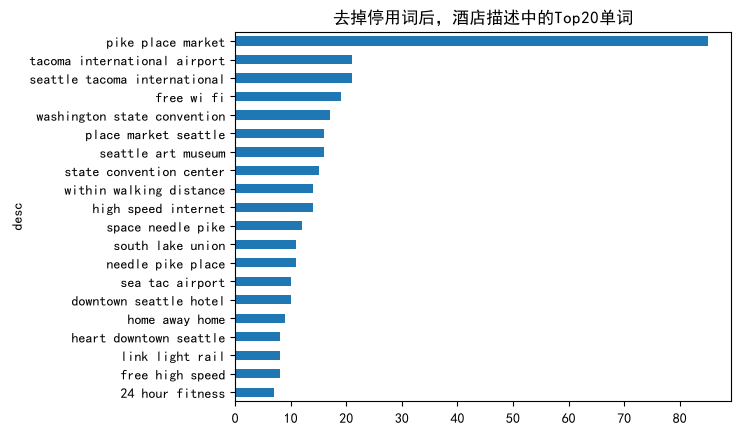

In [ ]:
'''
因为 kind='barh' 是水平条形图（bar horizontal）：

图表类型	分类轴	数值轴
bar	x 轴（底部）	y 轴（左侧）
barh	y 轴（左侧）	x 轴（底部）
barh 就是交换了 x/y 的角色：
'''
df1.groupby('desc').sum()['count'].sort_values().plot(kind='barh', title='去掉停用词后，酒店描述中的Top20单词')
plt.show()

### sklearn 的停用词集合相对较小，且不含 "don't"、"should've" 这类带撇号的形式）


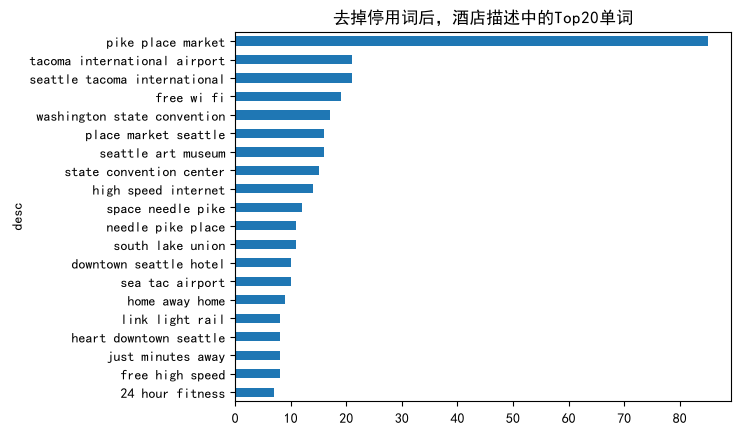

In [ ]:
# 得到酒店描述中n-gram特征中的TopK个
def get_top_n_words(corpus, n=1, k=None):
    # 统计ngram词频矩阵
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    """
    print('feature names:')
    print(vec.get_feature_names())
    print('bag of words:')
    print(bag_of_words.toarray())
    """
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # 按照词频从大到小排序
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:k]
common_words = get_top_n_words(df['desc'], 3, 20)
#print(common_words)
df2 = pd.DataFrame(common_words, columns = ['desc' , 'count'])
df2.groupby('desc').sum()['count'].sort_values().plot(kind='barh', title='去掉停用词后，酒店描述中的Top20单词')
plt.show()

In [41]:
df1==df2

,desc,count
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True
5,True,True
6,True,True
7,True,True
8,True,True
9,True,True


In [43]:
compare=df1.compare(df2)
print(compare)

Empty DataFrame
Columns: []
Index: []


In [45]:
##NLTK stopwords	NLTK 语料库	❌ 仅下载未用	经典全面，但需额外下载
import nltk
nltk.download('stopwords')

ModuleNotFoundError: No module named 'nltk'

In [46]:
# 文本预处理
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
BAD_SYMBOLS_RE = re.compile('[^0-9a-z #+_]')
# 使用自定义的英文停用词列表替代nltk的stopwords
STOPWORDS = ENGLISH_STOPWORDS
# 对文本进行清洗
def clean_text(text):
    # 全部小写
    text = text.lower()
    # 用空格替代一些特殊符号，如标点
    text = REPLACE_BY_SPACE_RE.sub(' ', text)
    # 移除BAD_SYMBOLS_RE
    text = BAD_SYMBOLS_RE.sub('', text)
    # 从文本中去掉停用词
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) 
    return text
# 对desc字段进行清理，apply针对某列
df['desc_clean'] = df['desc'].apply(clean_text)
print(df['desc_clean'])

0      located southern tip lake union hilton garden ...
1      located citys vibrant core sheraton grand seat...
2      located heart downtown seattle awardwinning cr...
3      whats near hotel downtown seattle location bet...
4      situated amid incredible shopping iconic attra...
                             ...                        
147    located queen anne district halcyon suite du j...
148    block world famous space needle seattle center...
149    stay alfred wall street resides heart belltown...
150    perfect marriage heightened convenience unbeat...
151    yes true every room citizenm best every room s...
Name: desc_clean, Length: 152, dtype: str


<>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
C:\Users\zhaozhen\AppData\Local\Temp\ipykernel_36572\3243593116.py:2: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')


In [47]:
# 建模
df.set_index('name', inplace = True)
# 使用TF-IDF提取文本特征，使用自定义停用词列表, 1元特征（1000） + 2元特征（1200） + 3元特征（1147）=3347
tf = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=0.01, stop_words=list(ENGLISH_STOPWORDS))
# 针对desc_clean提取tfidf
tfidf_matrix = tf.fit_transform(df['desc_clean'])
print('TFIDF feature names:')
#print(tf.get_feature_names_out())
print(len(tf.get_feature_names_out()))
print('tfidf_matrix:',tfidf_matrix)

TFIDF feature names:
3347
tfidf_matrix: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16877 stored elements and shape (152, 3347)>
  Coords	Values
  (0, 1719)	0.0653556302128929
  (0, 1626)	0.12491293982326873
  (0, 3081)	0.134097856000268
  (0, 1369)	0.07476039423996281
  (0, 1221)	0.07672194770445162
  (0, 1543)	0.049246645770058876
  (0, 2523)	0.04723838259568511
  (0, 820)	0.03267781510644645
  (0, 1413)	0.027559455988603942
  (0, 2190)	0.08406257987423404
  (0, 435)	0.08558268592593565
  (0, 1653)	0.067048928000134
  (0, 2018)	0.057864011823134734
  (0, 1387)	0.04979549787130613
  (0, 1781)	0.07132229854860234
  (0, 1564)	0.05628009710194575
  (0, 622)	0.08406257987423404
  (0, 1519)	0.050359388872797
  (0, 174)	0.06462486666561425
  (0, 1248)	0.0872351140221
  (0, 367)	0.09098742549726888
  (0, 1877)	0.09098742549726888
  (0, 1223)	0.0872351140221
  (0, 1127)	0.09098742549726888
  (0, 867)	0.0788903444584315
  :	:
  (151, 466)	0.11264376737990651
  (151, 589)	0.10

In [ ]:
# 计算酒店之间的余弦相似度（线性核函数）
cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)
print(cosine_similarities)
print(cosine_similarities.shape)


[[1.         0.03930478 0.09970189 ... 0.04875507 0.02296214 0.0262131 ]
 [0.03930478 1.         0.05892777 ... 0.06130707 0.01516305 0.03543109]
 [0.09970189 0.05892777 1.         ... 0.08718294 0.04218405 0.04985284]
 ...
 [0.04875507 0.06130707 0.08718294 ... 1.         0.05751589 0.03948025]
 [0.02296214 0.01516305 0.04218405 ... 0.05751589 1.         0.01602277]
 [0.0262131  0.03543109 0.04985284 ... 0.03948025 0.01602277 1.        ]]
(152, 152)


In [51]:
indices = pd.Series(df.index) #df.index是酒店名称
print(indices)

0               Hilton Garden Seattle Downtown
1                       Sheraton Grand Seattle
2                Crowne Plaza Seattle Downtown
3                Kimpton Hotel Monaco Seattle 
4                           The Westin Seattle
                        ...                   
147                  The Halcyon Suite Du Jour
148                                Vermont Inn
149                 Stay Alfred on Wall Street
150         Pike's Place Lux Suites by Barsala
151    citizenM Seattle South Lake Union hotel
Name: name, Length: 152, dtype: str


In [52]:
# 基于相似度矩阵和指定的酒店name，推荐TOP10酒店
def recommendations(name, cosine_similarities = cosine_similarities):
    recommended_hotels = []
    # 找到想要查询酒店名称的idx
    idx = indices[indices == name].index[0]
    print('idx=', idx)
    # print('cosine_similarities[idx]:',cosine_similarities[idx])
    # 对于idx酒店的余弦相似度向量按照从大到小进行排序
    score_series = pd.Series(cosine_similarities[idx]).sort_values(ascending = False)
    # 取相似度最大的前10个（除了自己以外）
    top_10_indexes = list(score_series.iloc[1:11].index)
    # 放到推荐列表中
    for i in top_10_indexes:
        recommended_hotels.append(list(df.index)[i])
    return recommended_hotels
print(recommendations('Hilton Seattle Airport & Conference Center'))
print(recommendations('The Bacon Mansion Bed and Breakfast'))


idx= 49
['Embassy Suites by Hilton Seattle Tacoma International Airport', 'DoubleTree by Hilton Hotel Seattle Airport', 'Seattle Airport Marriott', 'Four Points by Sheraton Downtown Seattle Center', 'Motel 6 Seattle Sea-Tac Airport South', 'Hampton Inn Seattle/Southcenter', 'Radisson Hotel Seattle Airport', 'Knights Inn Tukwila', 'Hotel Hotel', 'Home2 Suites by Hilton Seattle Airport']
idx= 116
['11th Avenue Inn Bed and Breakfast', 'Shafer Baillie Mansion Bed & Breakfast', 'Gaslight Inn', 'Bed and Breakfast Inn Seattle', 'Chittenden House Bed and Breakfast', 'Hyatt House Seattle', 'Mozart Guest House', 'Silver Cloud Hotel - Seattle Broadway', 'WorldMark Seattle - The Camlin', 'Pensione Nichols Bed and Breakfast']
